# Tissue Classification — Walkthrough


In [1]:
import os
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile
import torch
from PIL import Image

sns.set_theme(style="whitegrid")


# §3 — Model and training

Three decisions drive this section:

**Backbone : ResNet-50, ImageNet-pretrained.** 
- Well-understood, the right capacity for *n = 400*, with self-contained weights (no auth, no extra downloads beyond torchvision).
- Pathology-SSL foundation models (UNI, Virchow, CTransPath, Lunit-DINO) would almost certainly give a meaningful lift on H&E classification, and they're included in the Future Work section. For this, let's keep the backbone simple.

**Training protocol** 

| Choice          | Value                             | Why                                                                 |
|-----------------|-----------------------------------|---------------------------------------------------------------------|
| Loss            | `CrossEntropyLoss`                | 4 classes, perfectly balanced → no weighting needed                 |
| Optimizer       | `AdamW`                           | Robust default; decouples weight decay from the gradient step       |
| Learning rate   | 1e-4                              | Standard for pretrained-backbone fine-tuning                        |
| Weight decay    | 1e-4                              | Light regularisation appropriate for *n = 400*                      |
| Scheduler       | Cosine annealing                  | Smooth LR decay; no step hyperparameters to tune                    |
| Early stopping  | patience 7 on val macro-F1        | Prevents overfitting without hand-tuning the epoch count            |
| Epochs          | 30 (fixed across folds)           | Chosen from a brief pilot; fixed for fair cross-fold comparison     |

**Evaluation protocol: Stratified 5-fold CV.** 

At *n = 400* a single holdout is dominated by sampling noise.
We report **mean ± std** of image-level macro-F1, accuracy, and balanced accuracy
across 5 folds. Fold indices are saved alongside the shipped checkpoint. Per-epoch validation
during training uses a single centre-crop tile for speed; full image-level grid + flip-TTA
evaluation is a separate pass in §5.

All of this lives in `tissue.py` as `build_model`, `TrainConfig`, `train_one_fold`, and
`run_cv`. The notebook from here on *uses* those functions; it does not redefine them.


#### Build the model, 

- Let's confirm it lands on the expected device, and do a single forward pass.
- We also print the parameter count to  see that only the classification head is truly "new" — everything else is initialised from ImageNet-V2 weights.


In [17]:

from tissue import build_model, pick_device, TrainConfig, CLASSES

device = pick_device()
print(f"device: {device}")

model = build_model(num_classes=len(CLASSES))

n_params    = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ResNet-50 > {len(CLASSES)} classes: {n_params/1e6:.1f}M params ({n_trainable/1e6:.1f}M trainable)")
print(f"swapped head: {model.fc}")

model = model.to(device).eval()
with torch.no_grad():
    x = torch.randn(2, 3, 512, 512, device=device)
    y = model(x)
print(f"forward pass ok: input {tuple(x.shape)} > output {tuple(y.shape)} on {y.device}")


device: cuda
ResNet-50 > 4 classes: 23.5M params (23.5M trainable)
swapped head: Linear(in_features=2048, out_features=4, bias=True)
forward pass ok: input (2, 3, 512, 512) > output (2, 4) on cuda:0


### Running the cross-validation

The cell below runs the full 5-fold CV. On a single GPU we measured ~10 s/epoch, so the full
run is ~25 minutes. To avoid retraining whenever the notebook is re-executed, we
check `checkpoints/metrics.json` first and load cached results if they exist. Delete the
`checkpoints/` directory (or pass a different config) to force a retrain.

Four things are saved at the end of CV, so it's  fully reproducible:

- **`checkpoints/final.pt`** — state_dict of the best fold by val macro-F1.
- **`checkpoints/splits.json`** — per-fold train/val indices + best-fold index.
- **`checkpoints/config.yaml`** — the exact `TrainConfig` used.
- **`checkpoints/metrics.json`** — per-fold metrics, epoch-by-epoch histories, and summary stats.


In [18]:
from pathlib import Path

from tissue import (
    TrainConfig, run_cv, save_cv_results, load_cv_metrics,
    encode_labels, pick_device,
)

CKPT_DIR = Path("checkpoints")

cv_metrics = load_cv_metrics(CKPT_DIR)
if cv_metrics is not None:
    print(f"Loaded cached CV metrics from {CKPT_DIR}/metrics.json "
          f"(delete {CKPT_DIR}/ to force a retrain)")
else:
    cfg = TrainConfig()  # epochs=30, n_splits=5, crop_size=512, batch_size=16, lr=1e-4
    print(f"Running {cfg.n_splits}-fold CV, {cfg.epochs} epochs/fold — ~25 min on a single GPU.\n")
    paths = df["path"].tolist()
    labels = encode_labels(df["class"].tolist())
    cv = run_cv(paths, labels, cfg, device=pick_device())
    save_cv_results(cv, CKPT_DIR)
    cv_metrics = load_cv_metrics(CKPT_DIR)
    print(f"\nSaved → {CKPT_DIR}/{{final.pt, splits.json, config.yaml, metrics.json}}")

print("\nSummary (mean ± std across 5 folds):")
for metric, stats in cv_metrics["summary"].items():
    per_fold_str = "  ".join(f"{v:.3f}" for v in stats["per_fold"])
    print(f"  {metric:20s}: {stats['mean']:.3f} ± {stats['std']:.3f}   per-fold: [{per_fold_str}]")
print(f"\nBest fold by val macro-F1: fold {cv_metrics['best_fold']}")


Loaded cached CV metrics from checkpoints/metrics.json (delete checkpoints/ to force a retrain)

Summary (mean ± std across 5 folds):
  accuracy            : 0.873 ± 0.035   per-fold: [0.912  0.838  0.887  0.825  0.900]
  balanced_accuracy   : 0.873 ± 0.035   per-fold: [0.913  0.838  0.887  0.825  0.900]
  macro_f1            : 0.872 ± 0.034   per-fold: [0.911  0.839  0.887  0.825  0.899]

Best fold by val macro-F1: fold 0


##### Training curves for one representative fold. By convention we show fold 0 unless a different fold is clearly more informative. Change `rep_fold` below to pick.


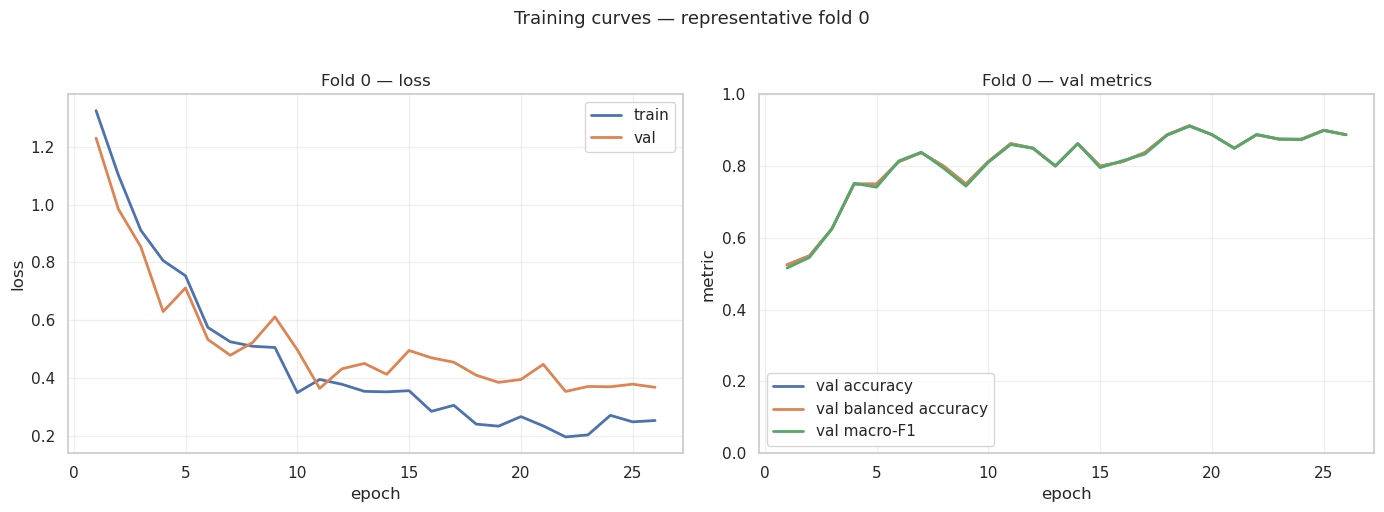

In [19]:

rep_fold = 0
hist = cv_metrics["fold_histories"][rep_fold]
epochs_x = range(1, len(hist["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_x, hist["train_loss"], label="train", linewidth=2)
ax1.plot(epochs_x, hist["val_loss"],   label="val",   linewidth=2)
ax1.set_xlabel("epoch")
ax1.set_ylabel("loss")
ax1.set_title(f"Fold {rep_fold} — loss")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(epochs_x, hist["val_accuracy"],          label="val accuracy",          linewidth=2)
ax2.plot(epochs_x, hist["val_balanced_accuracy"], label="val balanced accuracy", linewidth=2)
ax2.plot(epochs_x, hist["val_macro_f1"],          label="val macro-F1",          linewidth=2)
ax2.set_xlabel("epoch")
ax2.set_ylabel("metric")
ax2.set_ylim(0, 1)
ax2.set_title(f"Fold {rep_fold} — val metrics")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle(f"Training curves — representative fold {rep_fold}", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


#### Compact per-fold table so the reader can see dispersion, not just the mean.

In [20]:
rows = []
for metric, stats in cv_metrics["summary"].items():
    row = {"metric": metric, "mean": stats["mean"], "std": stats["std"]}
    for i, v in enumerate(stats["per_fold"]):
        row[f"fold{i}"] = v
    rows.append(row)

cv_df = pd.DataFrame(rows).set_index("metric")
cv_df.style.format("{:.3f}") if hasattr(cv_df, "style") else cv_df


,mean,std,fold0,fold1,fold2,fold3,fold4
metric,,,,,,,
accuracy,0.873,0.035,0.912,0.838,0.887,0.825,0.900
balanced_accuracy,0.873,0.035,0.913,0.838,0.887,0.825,0.900
macro_f1,0.872,0.034,0.911,0.839,0.887,0.825,0.899




- **Mean ± std** is the honest headline at *n = 400*: it captures both typical performance
  and sampling variation across splits.
- **Per-fold values** let us spot outliers. If one fold's macro-F1 sits far from the others,
  it's a prompt to look at the images that ended up in its val split. A single outlier fold
  usually means the data has a latent structure that the random split didn't control for.
- **Training curves (fold 0)** show train-loss decreasing smoothly while val-loss and val
  metrics track. Train-loss ↓ with val-loss ↑ would be overfitting, so the early stopping exists
  for exactly that case. 

